In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from path_config import PathConfig
paths = PathConfig()

In [2]:
dl_data = pd.read_excel(paths.dl_path, sheet_name='Series Formatted Data')
ul_data = pd.read_excel(paths.ul_path, sheet_name='Series Formatted Data')

dl_data = dl_data.drop(["Technology_Mode"],axis=1)
dl_data = dl_data.loc[:, ~dl_data.columns.str.contains('^Unnamed')]

dl_data = dl_data[dl_data["Latitude"].notna() | (dl_data["Longitude"].notna())]
ul_data = ul_data[ul_data["Latitude"].notna() | (ul_data["Longitude"].notna())]

ul_data = ul_data.drop(["Message","Technology_Mode"],axis=1)
ul_data = ul_data.loc[:, ~ul_data.columns.str.contains('^Unnamed')]

bs_data = pd.read_excel(paths.Hucre_Bilgileri)

In [3]:
dl_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 72478 entries, 2 to 72479
Data columns (total 54 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   Message                      72478 non-null  int64         
 1   Time                         72478 non-null  datetime64[ns]
 2   Longitude                    72478 non-null  float64       
 3   Latitude                     72478 non-null  float64       
 4   NR_UE_PCI_0                  2470 non-null   float64       
 5   NR_UE_RSRP_0                 1942 non-null   float64       
 6   NR_UE_RSRQ_0                 1942 non-null   float64       
 7   NR_UE_SINR_0                 1932 non-null   float64       
 8   NR_UE_Nbr_PCI_0              1413 non-null   float64       
 9   NR_UE_Nbr_PCI_1              504 non-null    float64       
 10  NR_UE_Nbr_PCI_2              127 non-null    float64       
 11  NR_UE_Nbr_PCI_3              24 non-null     f

Veri tiplerinin düzenlenmesi ve ayrıştırılması ileride işimizi kolaylaştıracak

In [4]:
target = ["Longitude", "Latitude"]

In [5]:
# PCI kolonları kategorik olarak algılanması için string'e çeviriyoruz
pci_cols = [col for col in dl_data.columns if col.find("PCI") != -1]
dl_data[pci_cols] = dl_data[pci_cols].astype("Int64").astype("str").replace("<NA>", np.nan)
ul_data[pci_cols] = ul_data[pci_cols].astype("Int64").astype("str").replace("<NA>", np.nan)

In [6]:
# Boolean kolonları kategorik olarak algılanması ayrıca matematiksel işlemlere tabi olmaması için bool'a çeviriyoruz
dl_data[[col for col in dl_data.columns if set(dl_data[col].unique()) == {0, 1}]] = dl_data[[
    col for col in dl_data.columns if set(dl_data[col].unique()) == {0, 1}]].astype("bool")

ul_data[[col for col in ul_data.columns if set(ul_data[col].unique()) == {0, 1}]] = ul_data[[
    col for col in ul_data.columns if set(ul_data[col].unique()) == {0, 1}]].astype("bool")

In [7]:
dl_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 72478 entries, 2 to 72479
Data columns (total 54 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   Message                      72478 non-null  int64         
 1   Time                         72478 non-null  datetime64[ns]
 2   Longitude                    72478 non-null  float64       
 3   Latitude                     72478 non-null  float64       
 4   NR_UE_PCI_0                  2470 non-null   object        
 5   NR_UE_RSRP_0                 1942 non-null   float64       
 6   NR_UE_RSRQ_0                 1942 non-null   float64       
 7   NR_UE_SINR_0                 1932 non-null   float64       
 8   NR_UE_Nbr_PCI_0              1413 non-null   object        
 9   NR_UE_Nbr_PCI_1              504 non-null    object        
 10  NR_UE_Nbr_PCI_2              127 non-null    object        
 11  NR_UE_Nbr_PCI_3              24 non-null     o

In [8]:
num_cols = [col for col in dl_data.columns if dl_data[col].dtype == "float64"]
num_cols.extend([col for col in ul_data.columns if ul_data[col].dtype == "float64"])
num_cols = list(set(num_cols) - set(target))

In [9]:
cat_cols = [col for col in dl_data.columns if dl_data[col].dtype == "object"]
cat_cols.extend([col for col in ul_data.columns if ul_data[col].dtype == "object"])
cat_cols = list(set(cat_cols))

In [10]:
bool_cols = [col for col in dl_data.columns if dl_data[col].dtype == "bool"]
bool_cols.extend([col for col in ul_data.columns if ul_data[col].dtype == "bool"])
bool_cols = list(set(bool_cols))

In [11]:
dl_data[[col for col in num_cols if col in dl_data.columns]].describe().T

,count,mean,std,min,25%,50%,75%,max
NR_UE_Nbr_RSRQ_1,504.0,-17.375000,3.962861,-34.70,-18.425,-16.80,-15.000,-11.00
NR_UE_RSRP_0,1942.0,-92.609629,20.777432,-150.60,-115.800,-87.00,-75.900,-50.80
NR_UE_SINR_0,1932.0,9.097516,13.047661,-18.10,-0.800,6.20,19.300,40.30
NR_UE_RSRQ_0,1942.0,-12.855458,3.085778,-37.60,-14.275,-11.80,-10.500,-10.30
NR_UE_Throughput_PDCP_DL,1994.0,77004.701876,34793.413219,0.00,74341.425,95907.84,97254.410,142432.84
App_Throughput_DL,911.0,80231.849638,27741.748984,99.17,83477.750,92938.86,94228.865,115802.21
NR_UE_RACH_Procedure_Count,41.0,21.000000,11.979149,1.00,11.000,21.00,31.000,41.00
NR_UE_BLER_DL_0,1934.0,8.165770,7.836393,0.00,3.800,8.10,10.200,100.00
NR_UE_RB_Num_DL_0,1934.0,91.225440,61.976589,4.00,37.000,76.00,123.000,270.00
NR_UE_Ack_As_Nack_DL_0,1934.0,2.326784,11.143272,0.00,0.000,0.00,0.000,168.00


In [57]:
for col in cat_cols:
    print(f"Unique values in {col}:")
    if col in dl_data.columns:
        print(f" --DL--\n {dl_data[col].unique()}")
    if col in ul_data.columns:
        print(f" --UL--\n {ul_data[col].unique()}")
    
    print(f"{'-'*50}\n")

Unique values in NR_UE_RRCReEst_EndResult:
 --DL--
 [nan 'Re-establishment failure after Request']
 --UL--
 [nan 'Re-establishment failure after Request']
--------------------------------------------------

Unique values in NR_UE_PCI_0:
 --DL--
 [nan '48' '76' '68' '3' '13' '23' '40' '30' '59' '278' '38']
 --UL--
 [nan '48' '76' '68' '3' '13' '23' '40' '30' '59' '246' '278' '38']
--------------------------------------------------

Unique values in NR_UE_CCE_AggregationLev_0:
 --DL--
 [NaN, 'LEVEL_2', 'LEVEL_1', 'LEVEL_16', 'LEVEL_4', 'LEVEL_8']
Categories (5, object): ['LEVEL_1' < 'LEVEL_2' < 'LEVEL_4' < 'LEVEL_8' < 'LEVEL_16']
 --UL--
 [NaN, 'LEVEL_2', 'LEVEL_1', 'LEVEL_16', 'LEVEL_4', 'LEVEL_8']
Categories (5, object): ['LEVEL_1' < 'LEVEL_2' < 'LEVEL_4' < 'LEVEL_8' < 'LEVEL_16']
--------------------------------------------------

Unique values in NR_UE_Nbr_PCI_1:
 --DL--
 [nan '76' '13' '23' '68' '59' '40' '48' '30' '38' '278']
 --UL--
 [nan '59' '13' '68' '23' '76' '48' '38' '40' '2

In [13]:
ordinal_cat = ["NR_UE_RI_DL_0", "NR_UE_CCE_AggregationLev_0", "NR_UE_Modulation_Avg_DL_0"]

In [14]:
dl_data[ordinal_cat[0]] = dl_data[ordinal_cat[0]].astype("category").cat.reorder_categories(['Rank1', 'Rank2', 'Rank3', 'Rank4'], ordered=True)
dl_data[ordinal_cat[1]] = dl_data[ordinal_cat[1]].astype("category").cat.reorder_categories(['LEVEL_1', 'LEVEL_2', 'LEVEL_4', 'LEVEL_8', 'LEVEL_16'], ordered=True)
dl_data[ordinal_cat[2]] = dl_data[ordinal_cat[2]].astype("category").cat.reorder_categories(['QPSK', '16QAM', '64QAM', '256QAM'], ordered=True)

In [15]:
ul_data[ordinal_cat[0]] = ul_data[ordinal_cat[0]].astype("category").cat.reorder_categories(['Rank1', 'Rank2', 'Rank3', 'Rank4'], ordered=True)
ul_data[ordinal_cat[1]] = ul_data[ordinal_cat[1]].astype("category").cat.reorder_categories(['LEVEL_1', 'LEVEL_2', 'LEVEL_4', 'LEVEL_8', 'LEVEL_16'], ordered=True) 
ul_data[ordinal_cat[2]] = ul_data[ordinal_cat[2]].astype("category").cat.reorder_categories(['QPSK', '16QAM', '64QAM', '256QAM'], ordered=True) 

In [16]:
def group_by_Time(df: pd.DataFrame,
                  num_cols: list[str],
                  cat_cols: list[str],
                  bool_cols: list[str],
                  ordinal_cat: list[str],
                  target: list[str]) -> pd.DataFrame:
    """
    Aynı 'Time' değerine sahip satırları birleştirir.
      - Numerik sütunların ortalamasını alır.
      - Kategorik ve ordinal sütunların modunu alır (ilk moda).
      - Bool sütunların max'ını alır.
    """

    # 1) her bölüm için agg sözlüğü hazırlayalım
    agg_dict: dict[str, object] = {}

    # Numerik: mean
    for c in num_cols:
        if c in df.columns:
            agg_dict[c] = 'mean'

    # Boolean: max
    for c in bool_cols:
        if c in df.columns:
            agg_dict[c] = 'max'

    # Kategorik ve ordinal: moda (mode)
    def first_mode(x: pd.Series):
        m = x.mode(dropna=True)
        return m.iloc[0] if not m.empty else np.nan

    for c in cat_cols + ordinal_cat + target:
        if c in df.columns:
            agg_dict[c] = first_mode

    # 2) groupby + agg
    grouped = (
        df
        .groupby('Time', as_index=False)
        .agg(agg_dict)
    )

    return grouped

In [17]:
grouped_dl = group_by_Time(dl_data, num_cols, cat_cols, bool_cols, ordinal_cat, target)
grouped_ul = group_by_Time(ul_data, num_cols, cat_cols, bool_cols, ordinal_cat, target)

In [18]:
grouped_dl.to_csv(paths._processed_saha_olcum_dir / "grouped_dl.csv", index=False)
grouped_ul.to_csv(paths._processed_saha_olcum_dir / "grouped_ul.csv", index=False)

In [19]:
grouped_dl.shape[0] + grouped_ul.shape[0]

12189

In [20]:
len(list(set(dl_data["Time"].unique())) + list(set(ul_data["Time"].unique())))

12189

In [21]:
for col in grouped_dl.columns:
    if col in cat_cols:
        print(f"Unique values in {col}: \n ----\n {grouped_dl[col].unique()}",end=f"\n{'-'*50}\n")

Unique values in NR_UE_RRCReEst_EndResult: 
 ----
 [nan 'Re-establishment failure after Request']
--------------------------------------------------
Unique values in NR_UE_PCI_0: 
 ----
 [nan '48' '76' '68' '3' '13' '23' '40' '30' '59' '278' '38']
--------------------------------------------------
Unique values in NR_UE_CCE_AggregationLev_0: 
 ----
 [NaN, 'LEVEL_2', 'LEVEL_1', 'LEVEL_16', 'LEVEL_4', 'LEVEL_8']
Categories (5, object): ['LEVEL_1' < 'LEVEL_2' < 'LEVEL_4' < 'LEVEL_8' < 'LEVEL_16']
--------------------------------------------------
Unique values in NR_UE_Nbr_PCI_1: 
 ----
 [nan '76' '13' '23' '68' '59' '40' '48' '30' '38' '278']
--------------------------------------------------
Unique values in NR_UE_MCS_DL_0: 
 ----
 [nan '27 (64QAM OR 256QAM / Low SE -64QAM)'
 '21 (64QAM OR 256QAM / Low SE -16QAM)'
 '25 (64QAM OR 256QAM OR 1024 QAM / Low SE -64QAM)'
 '26 (64QAM OR 256QAM OR 1024 QAM / Low SE -64QAM)'
 '24 (64QAM OR 256QAM OR 1024 QAM / Low SE -64QAM)'
 '23 (64QAM OR 256Q

In [22]:
def visualize_missing_values(df, name):
    """
    Bir pandas DataFrame'deki eksik değerleri bir ısı haritası (heatmap) ile görselleştirir.

    Args:
        df (pd.DataFrame): Eksik değerleri görselleştirilecek olan DataFrame.
        name (str): Görselleştirmenin başlığında kullanılacak isim.
    """
    plt.figure(figsize=(24, df.shape[1] / 5))  
    sns.heatmap(df.isnull().T, cbar=False, cmap='viridis')
    plt.title(f'{name}\'deki Eksik Değerler')
    plt.xticks([])
    plt.tight_layout() # Etiketlerin sıkışmasını önler
    plt.show()

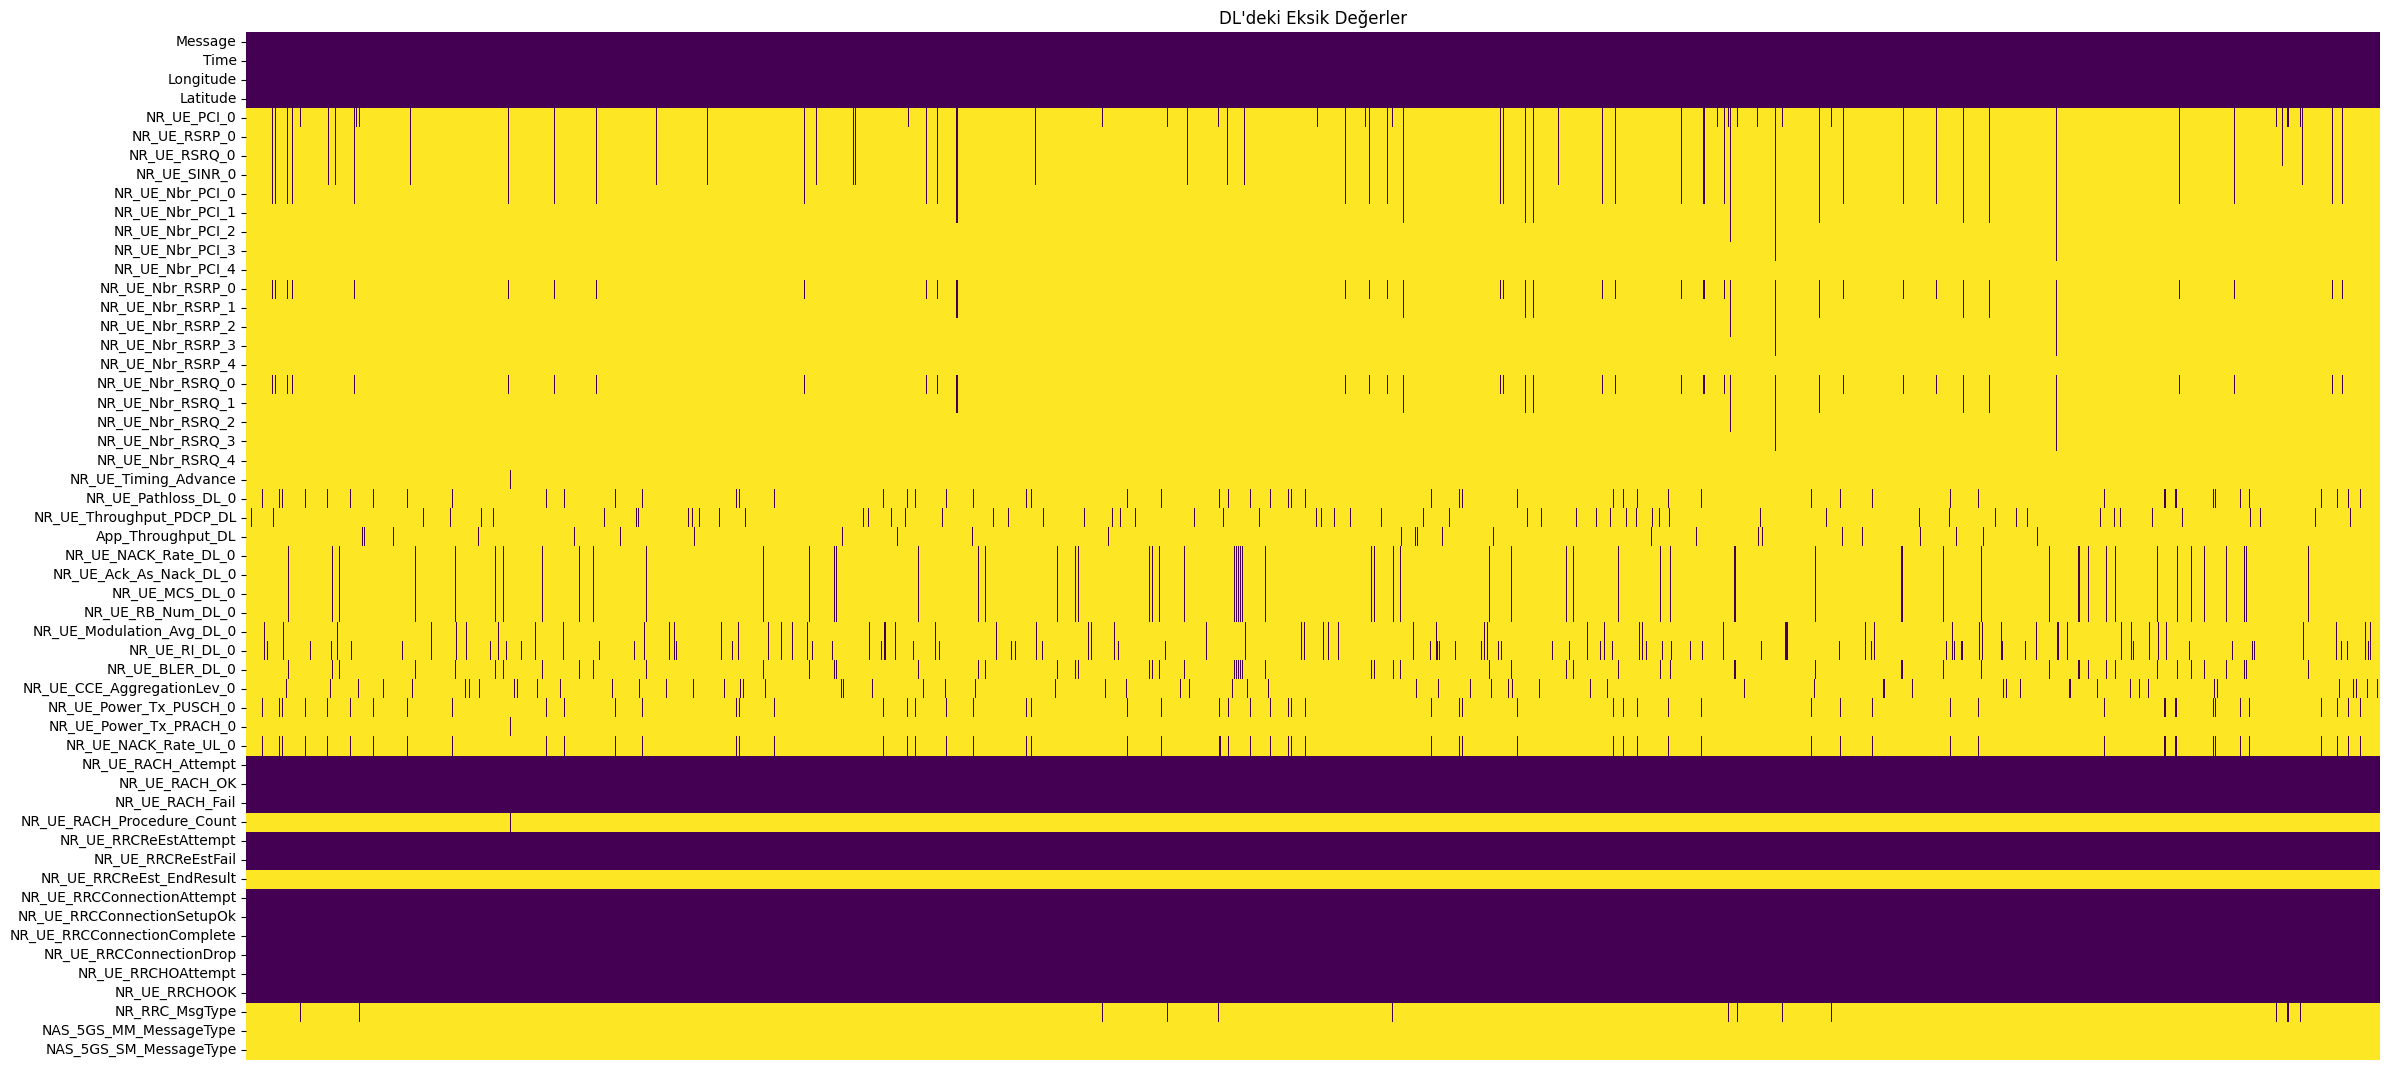

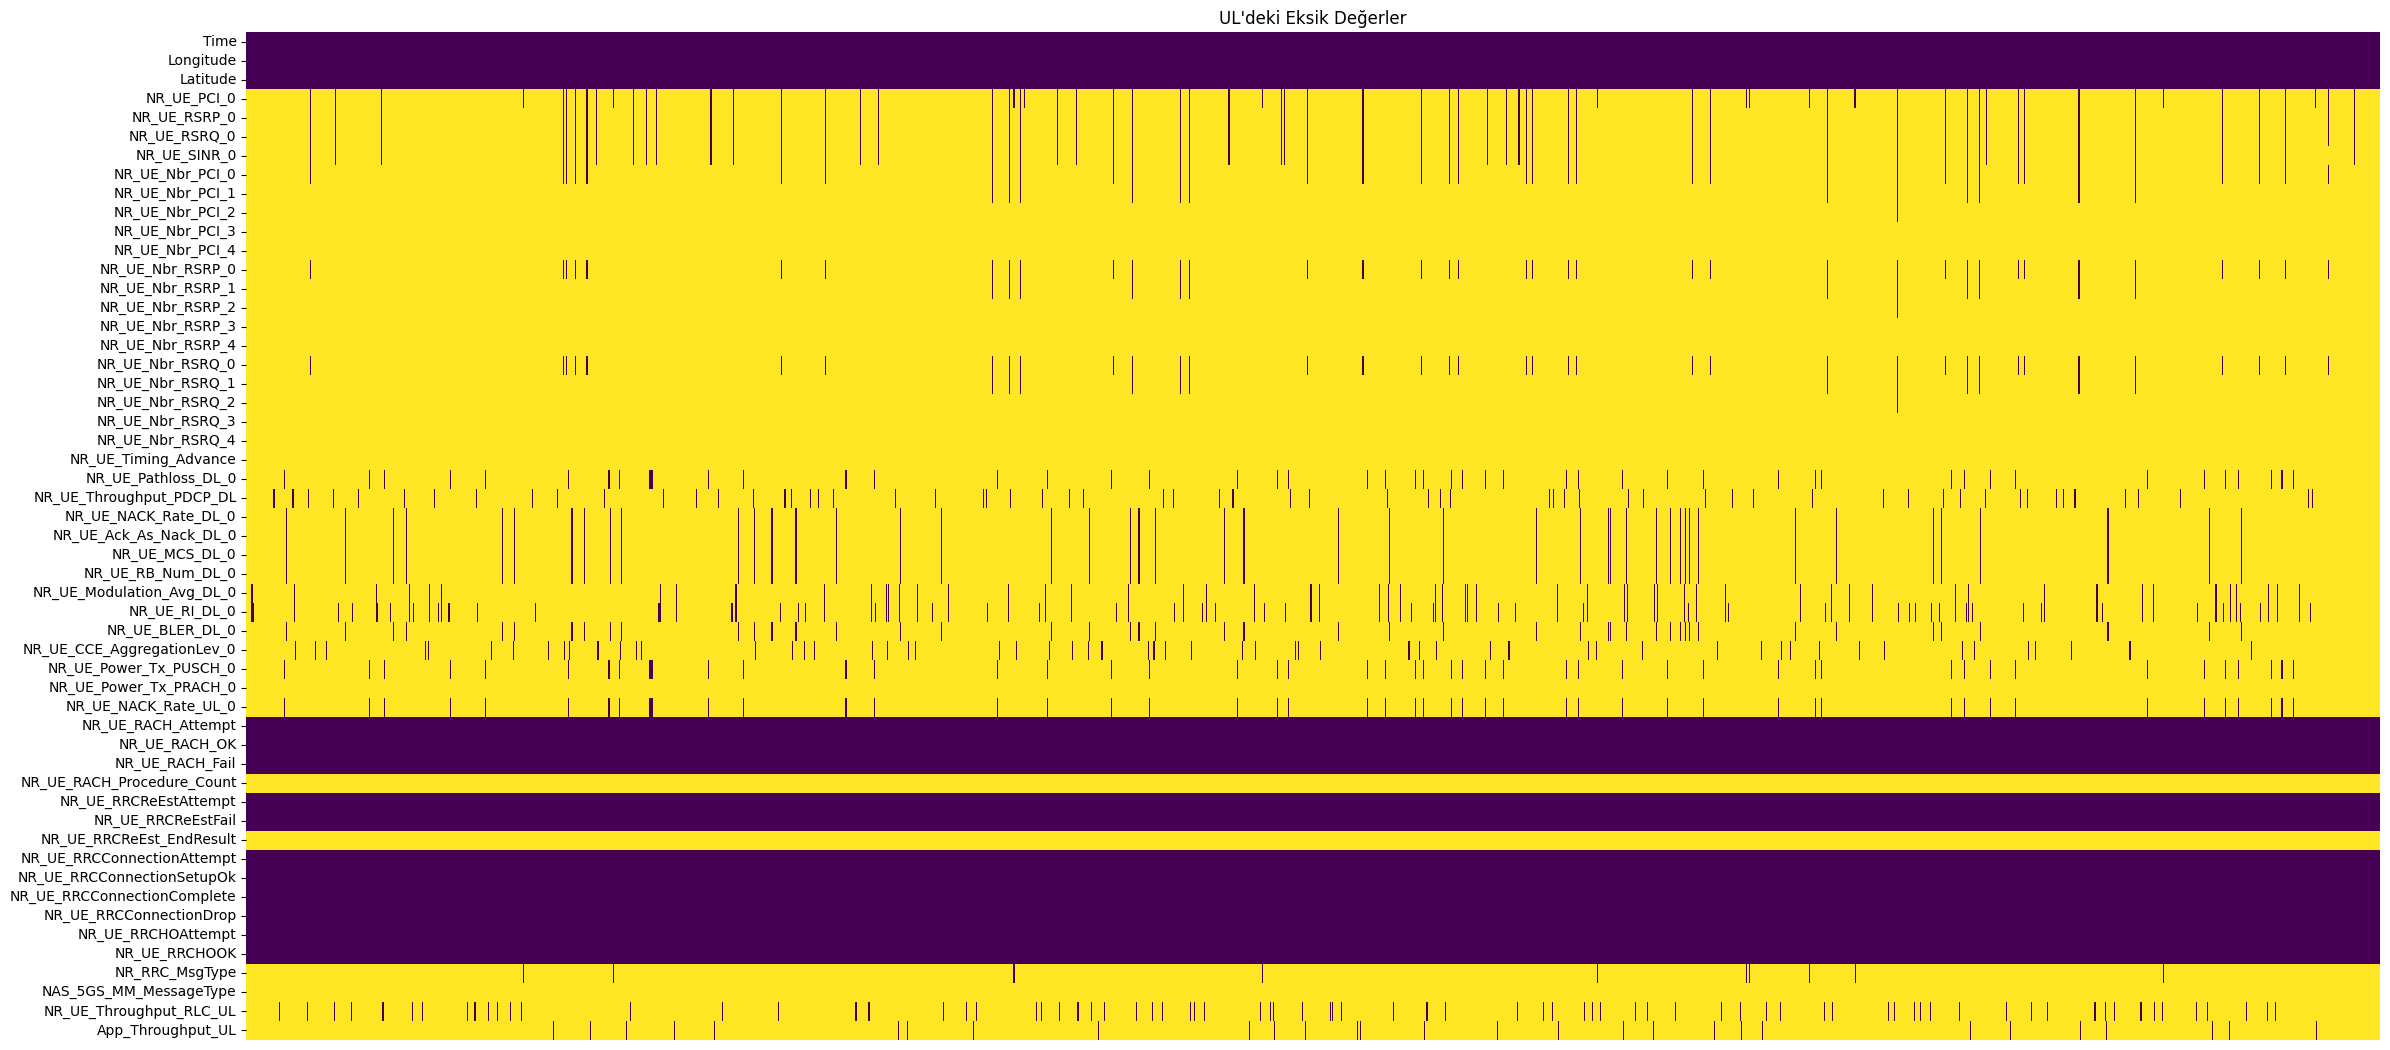

In [23]:
visualize_missing_values(dl_data, "DL")
visualize_missing_values(ul_data, "UL")

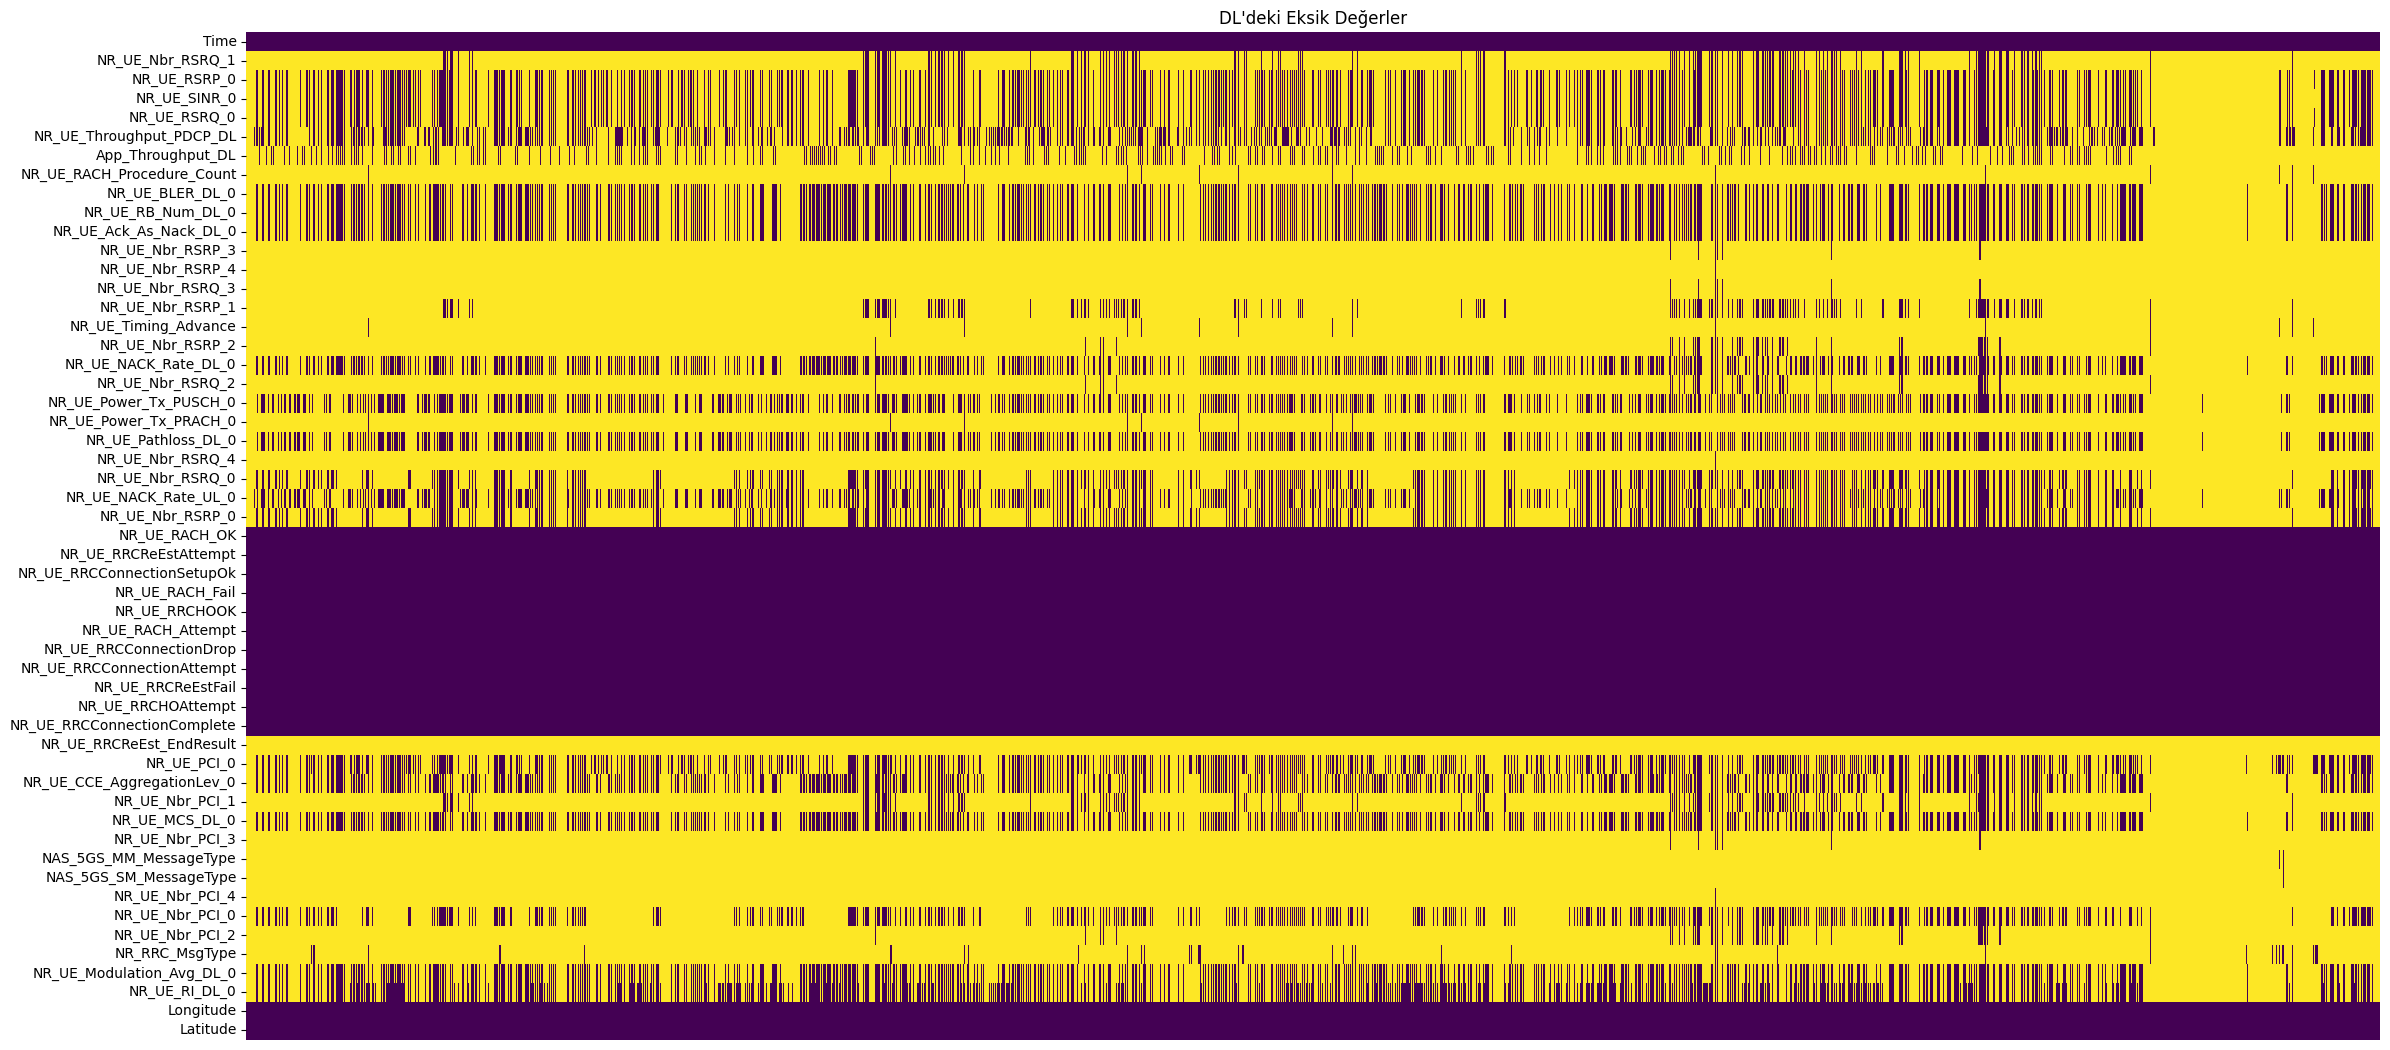

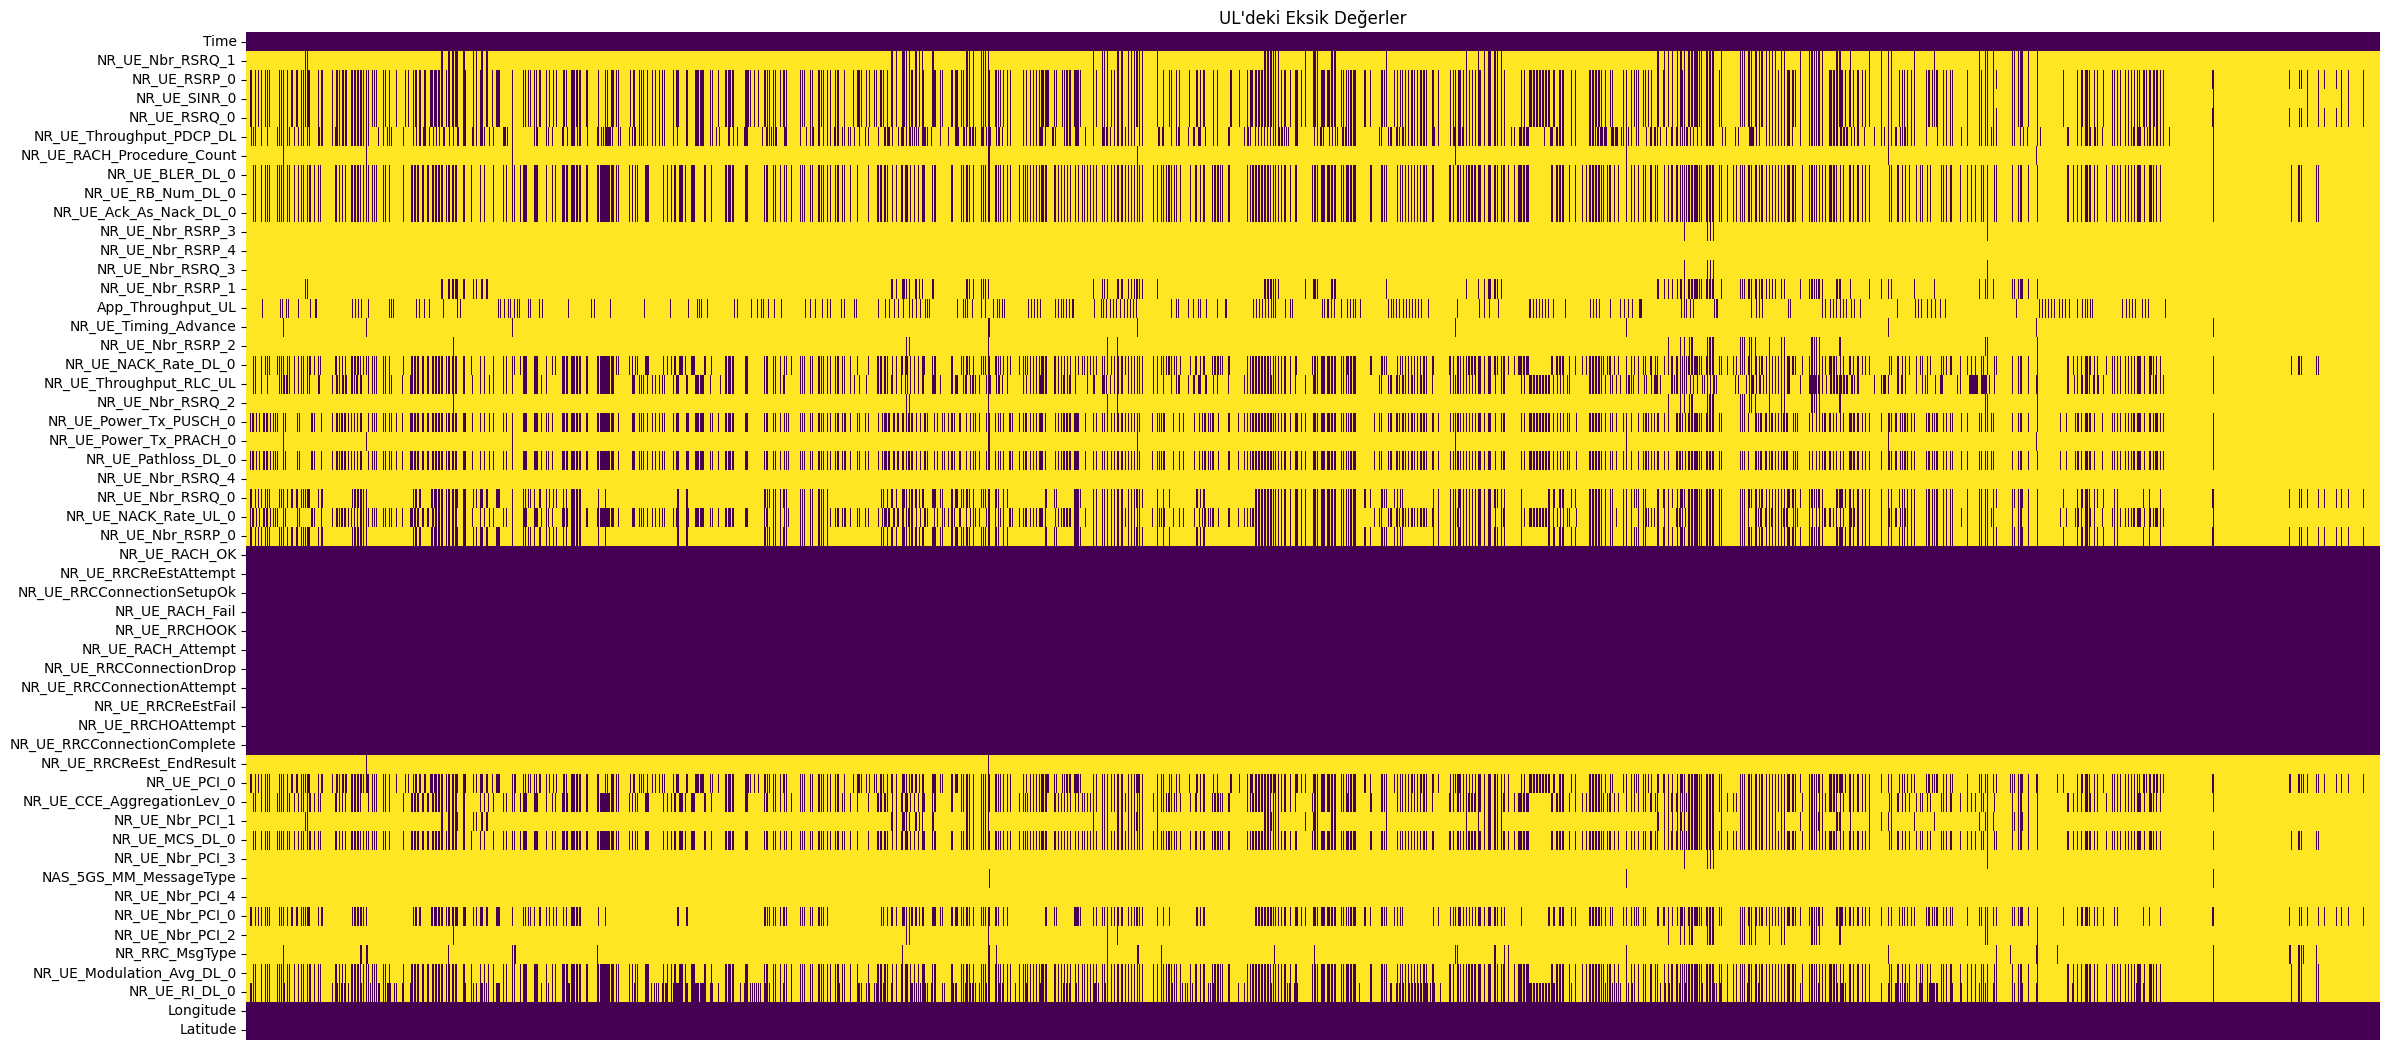

In [24]:
visualize_missing_values(grouped_dl, "DL")
visualize_missing_values(grouped_ul, "UL")

In [25]:
encoding_dl_pci = grouped_dl.copy()
encoding_ul_pci = grouped_ul.copy()
unique_pcis = [int(pcis) for pcis in bs_data["PCI "].unique()]

# Initialize all PCI columns for both DL and UL datasets
for i in unique_pcis:
    # Initialize main PCI columns
    encoding_dl_pci[f"NR_UE_PCI_0_{i}"] = 0
    encoding_ul_pci[f"NR_UE_PCI_0_{i}"] = 0
    
    # Set 1 for matching PCIs
    encoding_dl_pci.loc[encoding_dl_pci["NR_UE_PCI_0"] == str(i), f"NR_UE_PCI_0_{i}"] = 1
    encoding_ul_pci.loc[encoding_ul_pci["NR_UE_PCI_0"] == str(i), f"NR_UE_PCI_0_{i}"] = 1
    
    # Initialize neighbor PCI columns
    for k in range(5):
        encoding_dl_pci[f"NR_UE_Nbr_PCI_{k}_{i}"] = 0
        encoding_ul_pci[f"NR_UE_Nbr_PCI_{k}_{i}"] = 0
        
        # Set 1 for matching neighbor PCIs
        encoding_dl_pci.loc[encoding_dl_pci[f"NR_UE_Nbr_PCI_{k}"] == str(i), f"NR_UE_Nbr_PCI_{k}_{i}"] = 1
        encoding_ul_pci.loc[encoding_ul_pci[f"NR_UE_Nbr_PCI_{k}"] == str(i), f"NR_UE_Nbr_PCI_{k}_{i}"] = 1

# Initialize "other" columns
encoding_dl_pci["NR_UE_PCI_0_other"] = 0
encoding_ul_pci["NR_UE_PCI_0_other"] = 0

for k in range(5):
    encoding_dl_pci[f"NR_UE_Nbr_PCI_{k}_other"] = 0
    encoding_ul_pci[f"NR_UE_Nbr_PCI_{k}_other"] = 0

# Set "other" = 1 for values that are not NA and not in unique_pcis
# Main PCI
dl_mask = (~encoding_dl_pci["NR_UE_PCI_0"].isna()) & (~encoding_dl_pci["NR_UE_PCI_0"].isin([str(i) for i in unique_pcis]))
ul_mask = (~encoding_ul_pci["NR_UE_PCI_0"].isna()) & (~encoding_ul_pci["NR_UE_PCI_0"].isin([str(i) for i in unique_pcis]))
encoding_dl_pci.loc[dl_mask, "NR_UE_PCI_0_other"] = 1
encoding_ul_pci.loc[ul_mask, "NR_UE_PCI_0_other"] = 1

# Neighbor PCIs
for k in range(5):
    dl_mask = (~encoding_dl_pci[f"NR_UE_Nbr_PCI_{k}"].isna()) & (~encoding_dl_pci[f"NR_UE_Nbr_PCI_{k}"].isin([str(i) for i in unique_pcis]))
    ul_mask = (~encoding_ul_pci[f"NR_UE_Nbr_PCI_{k}"].isna()) & (~encoding_ul_pci[f"NR_UE_Nbr_PCI_{k}"].isin([str(i) for i in unique_pcis]))
    encoding_dl_pci.loc[dl_mask, f"NR_UE_Nbr_PCI_{k}_other"] = 1
    encoding_ul_pci.loc[ul_mask, f"NR_UE_Nbr_PCI_{k}_other"] = 1

#encoding_dl_pci.drop(columns=["NR_UE_PCI_0", "NR_UE_Nbr_PCI_0", "NR_UE_Nbr_PCI_1", "NR_UE_Nbr_PCI_2", "NR_UE_Nbr_PCI_3", "NR_UE_Nbr_PCI_4"], inplace=True)
# encoding_ul_pci.drop(columns=["NR_UE_PCI_0", "NR_UE_Nbr_PCI_0", "NR_UE_Nbr_PCI_1", "NR_UE_Nbr_PCI_2", "NR_UE_Nbr_PCI_3", "NR_UE_Nbr_PCI_4"], inplace=True)


In [26]:
print(  encoding_dl_pci[["NR_UE_PCI_0", "NR_UE_RSRP_0", "NR_UE_RSRQ_0", "NR_UE_SINR_0"]].dropna(how="all").isna().sum(),
        encoding_dl_pci[["NR_UE_Nbr_PCI_0", "NR_UE_Nbr_RSRP_0", "NR_UE_Nbr_RSRQ_0"]].dropna(how="all").isna().sum(),
        encoding_dl_pci[["NR_UE_Nbr_PCI_1", "NR_UE_Nbr_RSRP_1", "NR_UE_Nbr_RSRQ_1"]].dropna(how="all").isna().sum(),
        encoding_dl_pci[["NR_UE_Nbr_PCI_2", "NR_UE_Nbr_RSRP_2", "NR_UE_Nbr_RSRQ_2"]].dropna(how="all").isna().sum(),
        encoding_dl_pci[["NR_UE_Nbr_PCI_3", "NR_UE_Nbr_RSRP_3", "NR_UE_Nbr_RSRQ_3"]].dropna(how="all").isna().sum(),
        encoding_dl_pci[["NR_UE_Nbr_PCI_4", "NR_UE_Nbr_RSRP_4", "NR_UE_Nbr_RSRQ_4"]].dropna(how="all").isna().sum(), sep="\n\n")

#TODO KNN ile buradaki nanları doldurabiliriz şimdilik ortlama ile dolduracağım
#INFO buradaki nanlar pci lar var olmasına rağmen olmayan RSRP RSRQ SINR değerleri 


NR_UE_PCI_0      0
NR_UE_RSRP_0    57
NR_UE_RSRQ_0    57
NR_UE_SINR_0    64
dtype: int64

NR_UE_Nbr_PCI_0     0
NR_UE_Nbr_RSRP_0    0
NR_UE_Nbr_RSRQ_0    0
dtype: int64

NR_UE_Nbr_PCI_1     0
NR_UE_Nbr_RSRP_1    0
NR_UE_Nbr_RSRQ_1    0
dtype: int64

NR_UE_Nbr_PCI_2     0
NR_UE_Nbr_RSRP_2    0
NR_UE_Nbr_RSRQ_2    0
dtype: int64

NR_UE_Nbr_PCI_3     0
NR_UE_Nbr_RSRP_3    0
NR_UE_Nbr_RSRQ_3    0
dtype: int64

NR_UE_Nbr_PCI_4     0
NR_UE_Nbr_RSRP_4    0
NR_UE_Nbr_RSRQ_4    0
dtype: int64


In [27]:
encoding_dl_pci[[col for col in encoding_dl_pci.columns if "PCI" in col]]

,NR_UE_PCI_0,NR_UE_Nbr_PCI_1,NR_UE_Nbr_PCI_3,NR_UE_Nbr_PCI_4,NR_UE_Nbr_PCI_0,NR_UE_Nbr_PCI_2,NR_UE_PCI_0_30,NR_UE_Nbr_PCI_0_30,NR_UE_Nbr_PCI_1_30,NR_UE_Nbr_PCI_2_30,...,NR_UE_Nbr_PCI_1_23,NR_UE_Nbr_PCI_2_23,NR_UE_Nbr_PCI_3_23,NR_UE_Nbr_PCI_4_23,NR_UE_PCI_0_other,NR_UE_Nbr_PCI_0_other,NR_UE_Nbr_PCI_1_other,NR_UE_Nbr_PCI_2_other,NR_UE_Nbr_PCI_3_other,NR_UE_Nbr_PCI_4_other
0,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,48,NaN,NaN,NaN,76,NaN,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5776,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5777,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5778,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5779,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [28]:
# DL
empty_map = (encoding_dl_pci["NR_UE_PCI_0"].notna() & encoding_dl_pci["NR_UE_RSRP_0"].isna())
encoding_dl_pci.loc[empty_map, "NR_UE_RSRP_0"] = encoding_dl_pci.loc[empty_map, "NR_UE_RSRP_0"].fillna(
    encoding_dl_pci.groupby("NR_UE_PCI_0")["NR_UE_RSRP_0"].transform("mean"))

empty_map = (encoding_dl_pci["NR_UE_PCI_0"].notna() & encoding_dl_pci["NR_UE_RSRQ_0"].isna())
encoding_dl_pci.loc[empty_map, "NR_UE_RSRQ_0"] = encoding_dl_pci.loc[empty_map, "NR_UE_RSRQ_0"].fillna(
    encoding_dl_pci.groupby("NR_UE_PCI_0")["NR_UE_RSRQ_0"].transform("mean"))

empty_map = (encoding_dl_pci["NR_UE_PCI_0"].notna() & encoding_dl_pci["NR_UE_SINR_0"].isna())
encoding_dl_pci.loc[empty_map, "NR_UE_SINR_0"] = encoding_dl_pci.loc[empty_map, "NR_UE_SINR_0"].fillna(
    encoding_dl_pci.groupby("NR_UE_PCI_0")["NR_UE_SINR_0"].transform("mean"))

# UL
empty_map = (encoding_ul_pci["NR_UE_PCI_0"].notna() & encoding_ul_pci["NR_UE_RSRP_0"].isna())
encoding_ul_pci.loc[empty_map, "NR_UE_RSRP_0"] = encoding_ul_pci.loc[empty_map, "NR_UE_RSRP_0"].fillna(
    encoding_ul_pci.groupby("NR_UE_PCI_0")["NR_UE_RSRP_0"].transform("mean"))

empty_map = (encoding_ul_pci["NR_UE_PCI_0"].notna() & encoding_ul_pci["NR_UE_RSRQ_0"].isna())
encoding_ul_pci.loc[empty_map, "NR_UE_RSRQ_0"] = encoding_ul_pci.loc[empty_map, "NR_UE_RSRQ_0"].fillna(
    encoding_ul_pci.groupby("NR_UE_PCI_0")["NR_UE_RSRQ_0"].transform("mean"))

empty_map = (encoding_ul_pci["NR_UE_PCI_0"].notna() & encoding_ul_pci["NR_UE_SINR_0"].isna())
encoding_ul_pci.loc[empty_map, "NR_UE_SINR_0"] = encoding_ul_pci.loc[empty_map, "NR_UE_SINR_0"].fillna(
    encoding_ul_pci.groupby("NR_UE_PCI_0")["NR_UE_SINR_0"].transform("mean"))

In LTE networks, the reporting range for RSRP is typically between -140 dBm and -44 dBm, with a resolution of 1 dB.<br>
For 5G New Radio (NR), the ranges differ, with Synchronization Signal RSRP (SS-RSRP) spanning from -30 dBm to -156 dBm and <br>
Channel State Information RSRP (CSI-RSRP) ranging from -45 dBm to -139 dBm. <br>
<br>
The typical reporting range for RSRQ in LTE is from -19.5 dB to -3 dB. <br>
In contrast, 5G NR employs a wider range for RSRQ, spanning from -43 dB to 20 dB for both SS-RSRQ and CSI-RSRQ. <br>
<br>
 It is worth noting that a minimum SINR of -20 dB is often required for the user equipment to reliably detect RSRP and RSRQ. <br>
 For 5G NR, SINR values for SS-SINR and CSI-SINR typically range from -23 dB to 40 dB , <br>
 and these values are often reported as a coded index from 0 to 127.

In [29]:
print(f"Max RSRP: {encoding_dl_pci[[col for col in encoding_dl_pci.columns if col.find("RSRP") != -1]].max().max()}",
      f"Min RSRP: {encoding_dl_pci[[col for col in encoding_dl_pci.columns if col.find("RSRP") != -1]].min().min()}","\n"
      f"Max RSRQ: {encoding_dl_pci[[col for col in encoding_dl_pci.columns if col.find("RSRQ") != -1]].max().max()}",
      f"Min RSRQ: {encoding_dl_pci[[col for col in encoding_dl_pci.columns if col.find("RSRQ") != -1]].min().min()}","\n"
      f"Max SINR: {encoding_dl_pci[[col for col in encoding_dl_pci.columns if col.find("SINR") != -1]].max().max()}",
      f"Min SINR: {encoding_dl_pci[[col for col in encoding_dl_pci.columns if col.find("SINR") != -1]].min().min()}",sep=" \n")
# Bakalım bizim verimizde de öylemi -evet

Max RSRP: -50.8 
Min RSRP: -155.9 

Max RSRQ: -10.3 
Min RSRQ: -43.0 

Max SINR: 40.3 
Min SINR: -18.1


In [30]:
for i in unique_pcis:
    encoding_dl_pci[f"{i}_RSRP"] = -157
    encoding_dl_pci[f"{i}_RSRQ"] = -44
    encoding_dl_pci[f"{i}_SINR"] = -20

for i in unique_pcis:
    encoding_dl_pci.loc[encoding_dl_pci[f"NR_UE_PCI_0"] == str(i), "NR_UE_RSRP_0"]
    

In [31]:
encoding_dl_pci.loc[encoding_dl_pci[f"NR_UE_PCI_0"] == str(i), "NR_UE_RSRP_0"]

914     -99.1
916     -91.2
918     -92.1
919     -91.8
922     -89.3
        ...  
3905   -115.3
3906   -115.6
3910   -117.9
3911   -120.8
3913   -118.1
Name: NR_UE_RSRP_0, Length: 90, dtype: float64

In [32]:
encoding_dl_pci.loc[encoding_dl_pci[f"NR_UE_PCI_0"].notna(), "NR_UE_RSRP_0"].isna().sum()

np.int64(0)

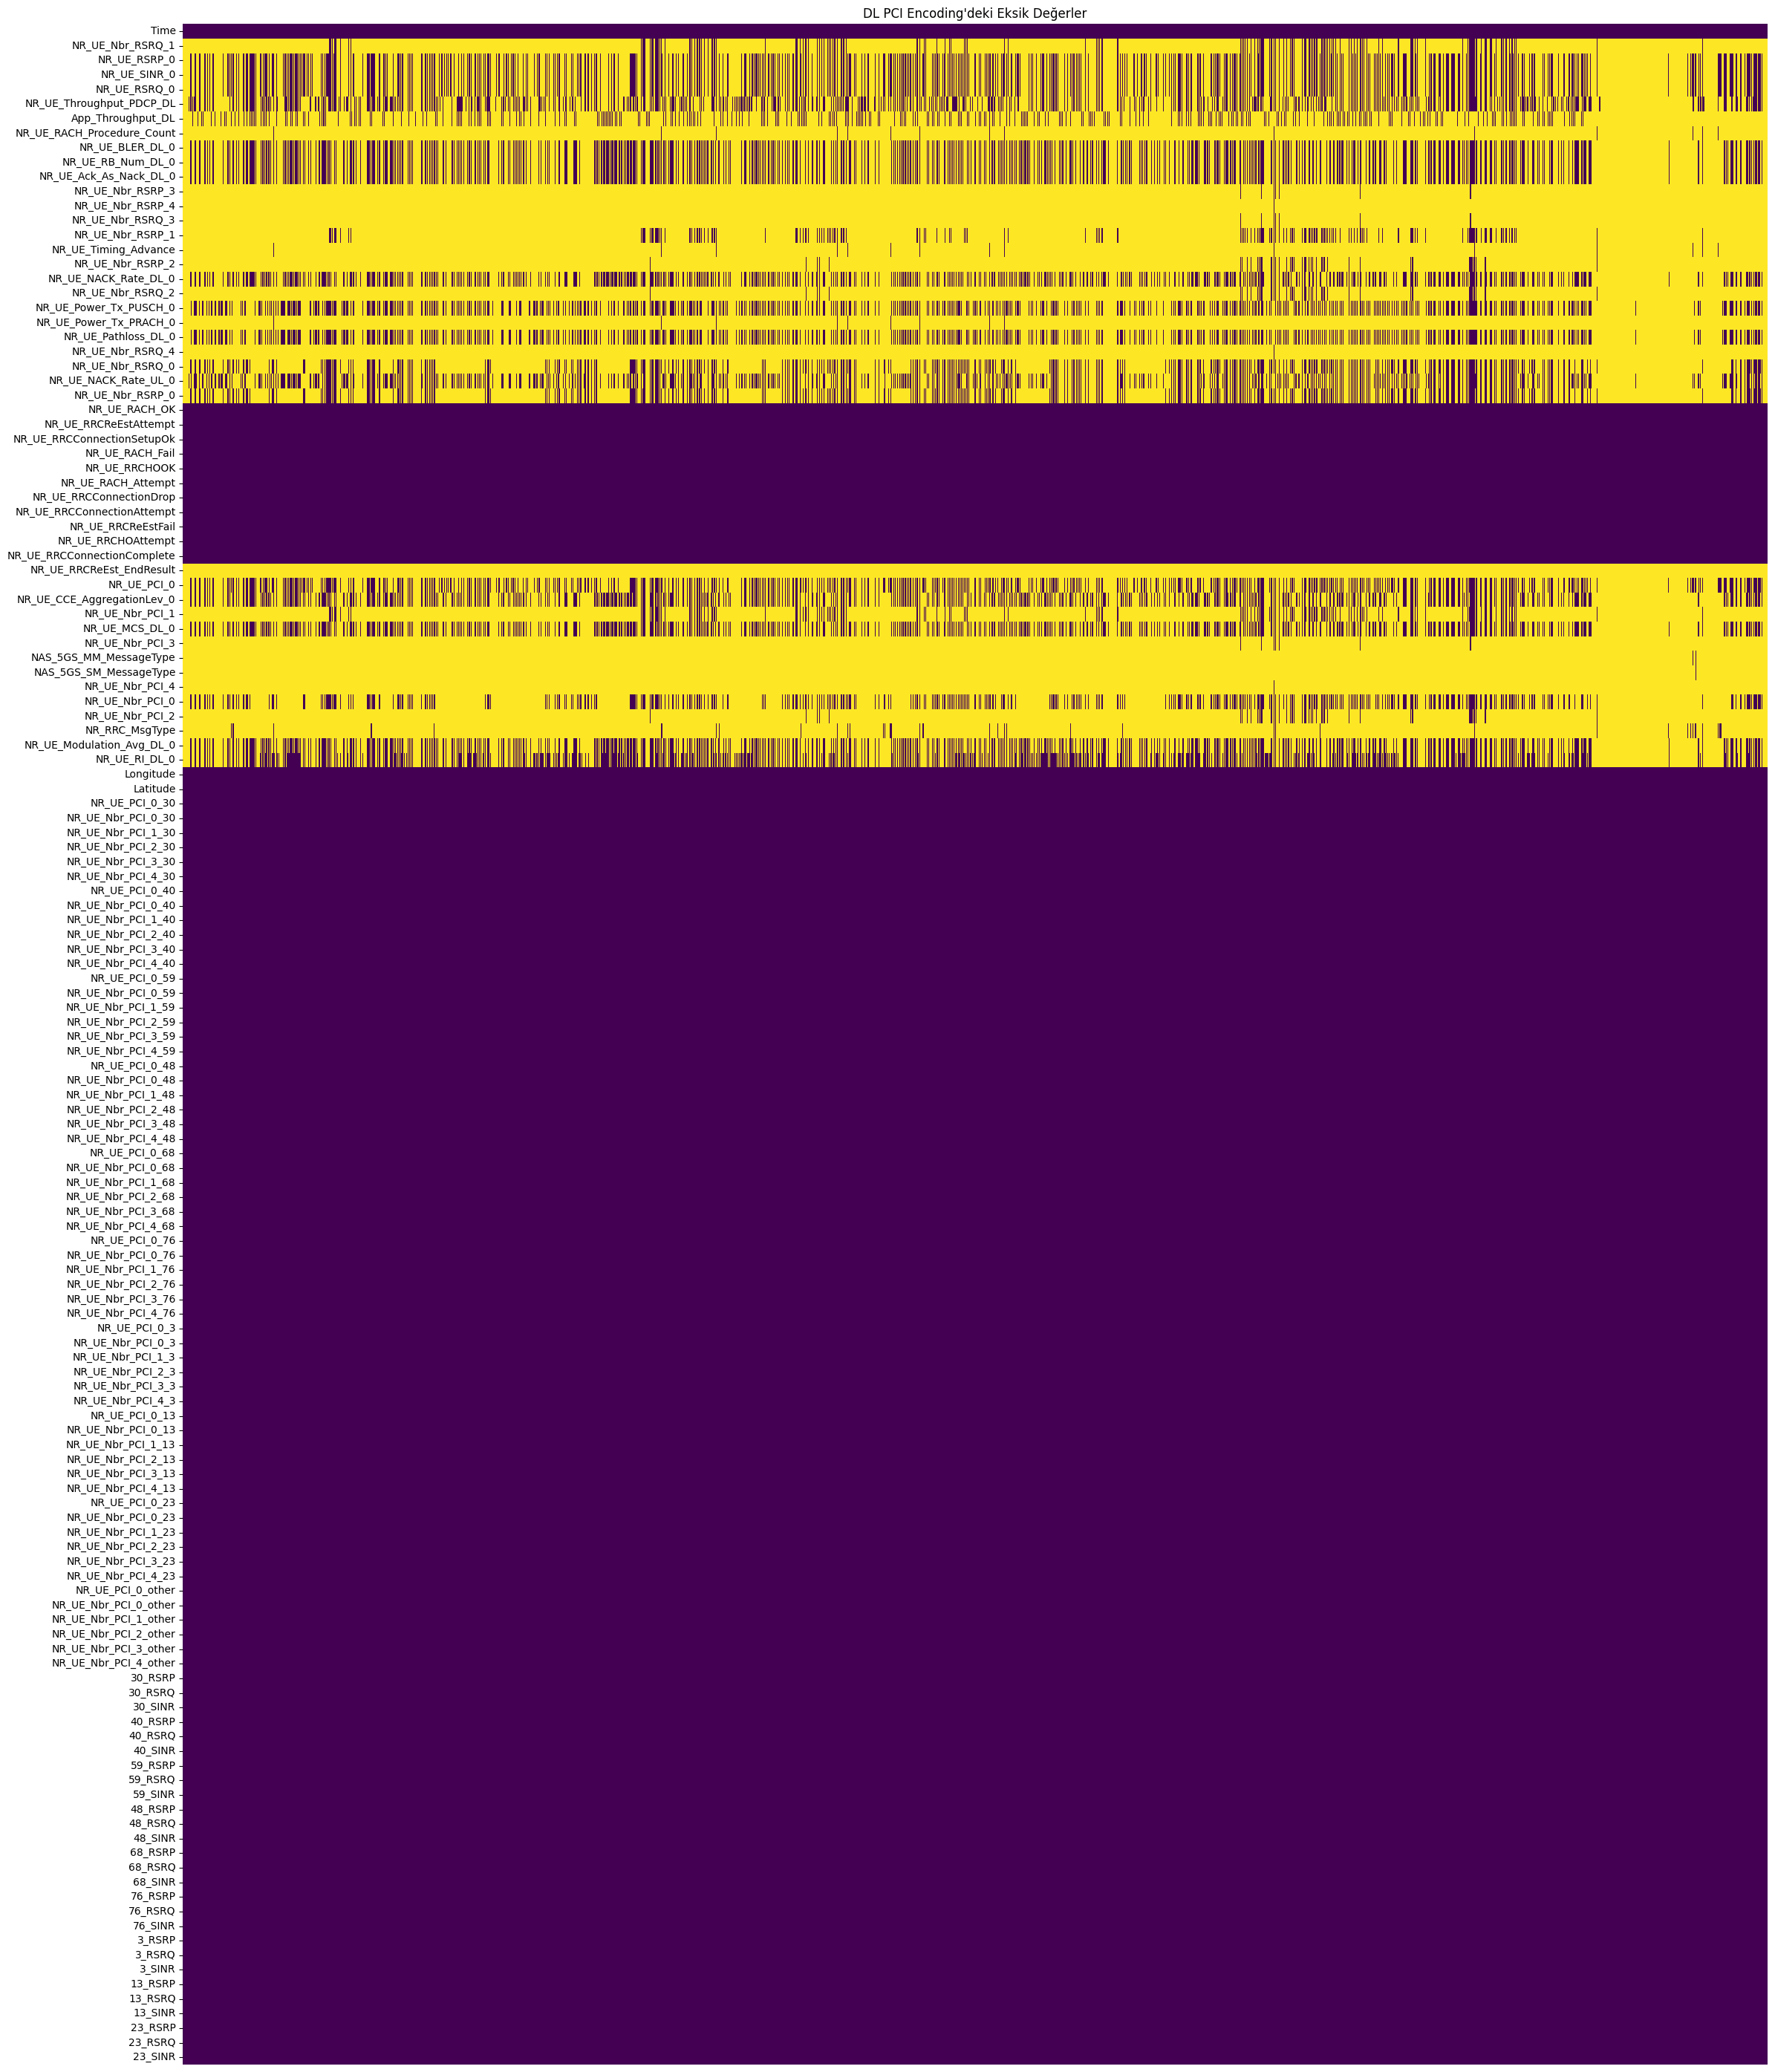

In [33]:
visualize_missing_values(encoding_dl_pci, "DL PCI Encoding")

In [34]:
encoding_dl_pci[[col for col in encoding_dl_pci.columns if encoding_dl_pci[col].isna().any() and encoding_dl_pci[col].dtype != "float64"]].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5781 entries, 0 to 5780
Data columns (total 14 columns):
 #   Column                      Non-Null Count  Dtype   
---  ------                      --------------  -----   
 0   NR_UE_RRCReEst_EndResult    1 non-null      object  
 1   NR_UE_PCI_0                 1981 non-null   object  
 2   NR_UE_CCE_AggregationLev_0  1916 non-null   category
 3   NR_UE_Nbr_PCI_1             494 non-null    object  
 4   NR_UE_MCS_DL_0              1929 non-null   object  
 5   NR_UE_Nbr_PCI_3             24 non-null     object  
 6   NAS_5GS_MM_MessageType      11 non-null     object  
 7   NAS_5GS_SM_MessageType      2 non-null      object  
 8   NR_UE_Nbr_PCI_4             2 non-null      object  
 9   NR_UE_Nbr_PCI_0             1398 non-null   object  
 10  NR_UE_Nbr_PCI_2             126 non-null    object  
 11  NR_RRC_MsgType              132 non-null    object  
 12  NR_UE_Modulation_Avg_DL_0   1928 non-null   category
 13  NR_UE_RI_DL_0     

In [35]:
encoding_ul_pci[[col for col in encoding_ul_pci.columns if encoding_ul_pci[col].isna().any() and encoding_ul_pci[col].dtype != "float64"]].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6408 entries, 0 to 6407
Data columns (total 13 columns):
 #   Column                      Non-Null Count  Dtype   
---  ------                      --------------  -----   
 0   NR_UE_RRCReEst_EndResult    3 non-null      object  
 1   NR_UE_PCI_0                 1848 non-null   object  
 2   NR_UE_CCE_AggregationLev_0  1722 non-null   category
 3   NR_UE_Nbr_PCI_1             438 non-null    object  
 4   NR_UE_MCS_DL_0              1770 non-null   object  
 5   NR_UE_Nbr_PCI_3             15 non-null     object  
 6   NAS_5GS_MM_MessageType      11 non-null     object  
 7   NR_UE_Nbr_PCI_4             1 non-null      object  
 8   NR_UE_Nbr_PCI_0             1308 non-null   object  
 9   NR_UE_Nbr_PCI_2             102 non-null    object  
 10  NR_RRC_MsgType              127 non-null    object  
 11  NR_UE_Modulation_Avg_DL_0   1768 non-null   category
 12  NR_UE_RI_DL_0               2366 non-null   category
dtypes: category(3), ob

In [36]:
encoding_dl_pci["NR_UE_MCS_DL_0"].unique()

array([nan, '27 (64QAM OR 256QAM / Low SE -64QAM)',
       '21 (64QAM OR 256QAM / Low SE -16QAM)',
       '25 (64QAM OR 256QAM OR 1024 QAM / Low SE -64QAM)',
       '26 (64QAM OR 256QAM OR 1024 QAM / Low SE -64QAM)',
       '24 (64QAM OR 256QAM OR 1024 QAM / Low SE -64QAM)',
       '23 (64QAM OR 256QAM OR 1024 QAM / Low SE -64QAM)',
       '20 (64QAM OR 256QAM / Low SE -16QAM)',
       '22 (64QAM OR 256QAM / Low SE -16QAM)',
       '13 (16QAM OR 64QAM / Low SE -QPSK)',
       '14 (16QAM OR 64QAM / Low SE -QPSK)',
       '16 (16QAM OR 64QAM OR 256QAM / Low SE -16QAM)',
       '12 (16QAM OR 64QAM / Low SE -QPSK)',
       '10 (16QAM OR 64QAM / Low SE -QPSK)',
       '9 (QPSK OR 16QAM OR 64QAM / Low SE -QPSK)',
       '17 (64QAM OR 256QAM / Low SE -16QAM)',
       '15 (16QAM OR 64QAM OR 256QAM / Low SE -16QAM)',
       '18 (64QAM OR 256QAM / Low SE -16QAM)',
       '19 (64QAM OR 256QAM / Low SE -16QAM)',
       '28 (64QAM / Low SE -64QAM)', '0 (QPSK)', '1 (QPSK)',
       '11 (16QAM OR 64QA

In [37]:
mcs_ul_map = {a:b for a,b in encoding_dl_pci["NR_UE_MCS_DL_0"].dropna().str.split(" ").apply(lambda x: (x[0], x[1:]))}
mcs_dl_map = {a:b for a,b in encoding_ul_pci["NR_UE_MCS_DL_0"].dropna().str.split(" ").apply(lambda x: (x[0], x[1:]))}

In [38]:
for k, v in mcs_ul_map.items():
    if k in mcs_dl_map:
        if mcs_dl_map[k] != v:
            print(f"Key: {k} - ul_Value: {v} - dl_Value: {mcs_dl_map[k]}")
    else:
        print(f"Key: {k} - ul_Value: {v} - dl_Value: None")

In [39]:
for k, v in mcs_dl_map.items():
    if k in mcs_ul_map:
        if mcs_ul_map[k] != v:
            print(f"Key: {k} - ul_Value: {v} - dl_Value: {mcs_ul_map[k]}")
    else:
        print(f"Key: {k} - ul_Value: {v} - dl_Value: None")

Key: 29 - ul_Value: ['(Reserved)'] - dl_Value: None


In [40]:
for k, v in mcs_ul_map.items():
    mcs_ul_map[k] = " ".join(v).strip("()")

for k, v in mcs_dl_map.items():
    mcs_dl_map[k] = " ".join(v).strip("()")

In [41]:
set(mcs_ul_map.values())

{'16QAM OR 64QAM / Low SE -QPSK',
 '16QAM OR 64QAM OR 256QAM / Low SE -16QAM',
 '64QAM / Low SE -64QAM',
 '64QAM OR 256QAM / Low SE -16QAM',
 '64QAM OR 256QAM / Low SE -64QAM',
 '64QAM OR 256QAM OR 1024 QAM / Low SE -64QAM',
 'QPSK',
 'QPSK OR 16QAM / Low SE -QPSK',
 'QPSK OR 16QAM OR 64QAM / Low SE -QPSK'}

## Modulasyon bilgisi içeren kolonlar

In [42]:
grouped_dl[["NR_UE_MCS_DL_0","NR_UE_Modulation_Avg_DL_0"]].dropna().head(10)

,NR_UE_MCS_DL_0,NR_UE_Modulation_Avg_DL_0
23,27 (64QAM OR 256QAM / Low SE -64QAM),256QAM
27,21 (64QAM OR 256QAM / Low SE -16QAM),256QAM
30,25 (64QAM OR 256QAM OR 1024 QAM / Low SE -64QAM),256QAM
34,25 (64QAM OR 256QAM OR 1024 QAM / Low SE -64QAM),256QAM
36,25 (64QAM OR 256QAM OR 1024 QAM / Low SE -64QAM),256QAM
40,26 (64QAM OR 256QAM OR 1024 QAM / Low SE -64QAM),256QAM
43,27 (64QAM OR 256QAM / Low SE -64QAM),256QAM
46,26 (64QAM OR 256QAM OR 1024 QAM / Low SE -64QAM),256QAM
48,26 (64QAM OR 256QAM OR 1024 QAM / Low SE -64QAM),256QAM
52,27 (64QAM OR 256QAM / Low SE -64QAM),256QAM



Bu değerler, 5G NR (New Radio) indirme (downlink) “Modulation and Coding Scheme” (MCS) yapılandırmaları içindeki modülasyon (QAM/QPSK) seviyelerini gösterir. Sütundaki her bir satır, o UE (User Equipment) için gözlemlenen veya atanabilen farklı modülasyon derecelerini ve “low spectral efficiency” (düşük spektral verimlilik) durumunda hangi modülasyonun kullanıldığını belirtir.

### Temel Modülasyon Türleri

| Kısaltma    | Açılımı                         | Bit/Sembol | Özellik                                        |
| :---------- | :------------------------------ | :--------- | :--------------------------------------------- |
| **QPSK**    | Quadrature Phase Shift Keying   | 2          | Çok sağlam, düşük veri hızı (düşük SE)         |
| **16QAM**   | 16-level Quadrature Amplitude   | 4          | Orta seviye veri hızı ve kapsama dengesi       |
| **64QAM**   | 64-level Quadrature Amplitude   | 6          | Yüksek veri hızı, daha yüksek SNR gerektiri    |
| **256QAM**  | 256-level Quadrature Amplitude  | 8          | Çok yüksek veri hızı, yüksek SNR şart          |
| **1024QAM** | 1024-level Quadrature Amplitude | 10         | En yüksek veri hızı, en yüksek SNR gereksinimi |


| Değer                                           | Açıklaması                                                                                                                      |
| :---------------------------------------------- | :------------------------------------------------------------------------------------------------------------------------------ |
| **QPSK**                                        | Bu UE için sadece **QPSK** modülasyonu kullanılmış; hem düşük hem de yüksek SE’de QPSK iletimi yapılmış.                        |
| **QPSK OR 16QAM / Low SE –QPSK**                | – Düşük SE’de QPSK<br>– Daha yüksek SE gerektiğinde 16QAM                                                                       |
| **QPSK OR 16QAM OR 64QAM / Low SE –QPSK**       | – Düşük SE’de QPSK<br>– Orta SE’de 16QAM<br>– Yüksek SE’de 64QAM                                                                |
| **16QAM OR 64QAM / Low SE –QPSK**               | – Düşük SE’de QPSK (geriye dönük değilse de, log’da düşük moda QPSK gözlemlenmiş)<br>– Orta SE’de 16QAM<br>– Yüksek SE’de 64QAM |
| **16QAM OR 64QAM OR 256QAM / Low SE –16QAM**    | – Düşük SE’de 16QAM<br>– Orta SE’de 64QAM<br>– Yüksek SE’de 256QAM                                                              |
| **64QAM / Low SE –64QAM**                       | – Hem düşük hem de yüksek SE’de **64QAM** (UE daha üst veya alt modülasyonu desteklemiyor ya da log’da başka gözlemlenmemiş)    |
| **64QAM OR 256QAM / Low SE –16QAM**             | – Düşük SE’de 16QAM<br>– Orta SE’de 64QAM<br>– Yüksek SE’de 256QAM                                                              |
| **64QAM OR 256QAM / Low SE –64QAM**             | – Düşük SE’de 64QAM<br>– Yüksek SE’de 256QAM                                                                                    |
| **64QAM OR 256QAM OR 1024 QAM / Low SE –64QAM** | – Düşük SE’de 64QAM<br>– Orta SE’de 256QAM<br>– En yüksek SE’de 1024QAM                                                         |


In [43]:
def parse_mcs(entry):
    """
    Parses the MCS entry to extract modulation schemes and their numeric values.
    Returns a Series with:
    - mods_list: List of modulation schemes
    - num_mods: Number of modulation schemes
    - min_mod: Minimum numeric value of modulation schemes
    - max_mod: Maximum numeric value of modulation schemes
    - low_se_mod: Low SE modulation scheme
    - low_se_num: Numeric value of low SE modulation scheme
    """

    mod_map = {
        'QPSK': 2,
        '16QAM': 4,
        '64QAM': 6,
        '256QAM': 8,
        '1024QAM': 10
    }

    if pd.isna(entry):
        return pd.Series({
            'mcs_key': None,
            'mods_list': [],
            'num_mods': 0,
            'min_mod': None,
            'max_mod': None,
            'low_se_mod': None,
            'low_se_num': None
        })
    
    # Default lists
    mods = []
    low_se = None

    mcs_key, entry = int(entry.split(" ")[0]), " ".join(entry.split(" ")[1:]).strip("()")
    
    if '/' in entry:
        # Split options and low SE part
        opts, low_part = entry.split('/', 1)
        # Extract low SE modulation
        low_se = low_part.strip().replace('Low SE -', '')
    else:
        opts = entry
        low_se = entry.strip()
    
    # Normalize spacing and split options
    opts_clean = opts.replace('OR', '|').replace(' ', '')
    mods = opts_clean.split('|')
    
    # Map to numeric values
    mod_nums = [mod_map.get(m, None) for m in mods]
    low_se_num = mod_map.get(low_se, None)
    
    return pd.Series({
        'mcs_key': mcs_key,
        'mods_list': mods,
        'num_mods': len(mods),
        'min_mod': min(mod_nums),
        'max_mod': max(mod_nums),
        'low_se_mod': low_se,
        'low_se_num': low_se_num
    })

In [44]:
feat_mcs_dl = encoding_dl_pci["NR_UE_MCS_DL_0"].apply(parse_mcs)
feat_mcs_ul = encoding_ul_pci["NR_UE_MCS_DL_0"].apply(parse_mcs)
encoding_dl_pci = pd.concat([encoding_dl_pci, feat_mcs_dl], axis=1)
encoding_ul_pci = pd.concat([encoding_ul_pci, feat_mcs_ul], axis=1)
#encoding_dl_pci.drop(columns=["NR_UE_MCS_DL_0"], inplace=True)
#encoding_ul_pci.drop(columns=["NR_UE_MCS_DL_0"], inplace=True)

## RACH_OK ?

In [45]:
grouped_dl[[col for col in grouped_dl.columns if col.find("Attempt") != -1]]

,NR_UE_RRCReEstAttempt,NR_UE_RACH_Attempt,NR_UE_RRCConnectionAttempt,NR_UE_RRCHOAttempt
0,False,False,False,False
1,False,False,False,False
2,False,False,False,False
3,False,False,False,False
4,False,False,False,False
...,...,...,...,...
5776,False,False,False,False
5777,False,False,False,False
5778,False,False,False,False
5779,False,False,False,False


In [46]:
grouped_dl[[col for col in grouped_dl.columns if col.find("RACH") != -1]]

,NR_UE_RACH_Procedure_Count,NR_UE_Power_Tx_PRACH_0,NR_UE_RACH_OK,NR_UE_RACH_Fail,NR_UE_RACH_Attempt
0,NaN,NaN,False,False,False
1,NaN,NaN,False,False,False
2,NaN,NaN,False,False,False
3,NaN,NaN,False,False,False
4,NaN,NaN,False,False,False
...,...,...,...,...,...
5776,NaN,NaN,False,False,False
5777,NaN,NaN,False,False,False
5778,NaN,NaN,False,False,False
5779,NaN,NaN,False,False,False


In [47]:
rach_list_dl = list(grouped_dl[grouped_dl["NR_UE_RACH_OK"] == True].index)
group_rach_dl = grouped_dl.iloc[rach_list_dl[0]-10:rach_list_dl[0]+10][["Time","NR_UE_RACH_OK", "NR_UE_PCI_0", "NR_UE_Nbr_PCI_0"]]
for i in rach_list_dl[1:]:
    group_rach_dl = pd.concat([group_rach_dl, grouped_dl.iloc[i-10:i+10][["Time","NR_UE_RACH_OK", "NR_UE_PCI_0", "NR_UE_Nbr_PCI_0"]]], axis=0)

In [48]:
group_rach_dl

,Time,NR_UE_RACH_OK,NR_UE_PCI_0,NR_UE_Nbr_PCI_0
162,2025-03-14 12:14:55.018,False,48,76
163,2025-03-14 12:14:55.316,False,NaN,NaN
164,2025-03-14 12:14:55.483,False,NaN,NaN
165,2025-03-14 12:14:55.499,False,48,76
166,2025-03-14 12:14:55.504,False,NaN,NaN
...,...,...,...,...
5605,2025-03-14 12:31:39.784,False,NaN,NaN
5606,2025-03-14 12:31:39.785,False,68,NaN
5607,2025-03-14 12:31:39.830,False,68,NaN
5608,2025-03-14 12:31:39.837,False,68,NaN


In [49]:
grouped_dl.loc[grouped_dl["NR_UE_RACH_OK"] == True, ["Time","NR_UE_PCI_0", "NR_UE_Nbr_PCI_0"]]

,Time,NR_UE_PCI_0,NR_UE_Nbr_PCI_0
172,2025-03-14 12:14:56.887,76,76
330,2025-03-14 12:15:24.849,68,68
565,2025-03-14 12:16:13.565,3,3
681,2025-03-14 12:16:36.409,13,13
914,2025-03-14 12:17:19.096,23,13
1123,2025-03-14 12:17:53.205,40,40
1453,2025-03-14 12:18:49.832,30,30
1745,2025-03-14 12:19:44.142,59,59
1912,2025-03-14 12:20:14.072,76,68
1945,2025-03-14 12:20:19.619,68,59


In [50]:
rach_list_ul = list(grouped_ul[grouped_ul["NR_UE_RACH_OK"] == True].index)
group_rach_ul = grouped_ul.iloc[rach_list_ul[0]-5:rach_list_ul[0]+5][["Time", "NR_UE_PCI_0","NR_UE_RACH_OK"]]
for i in rach_list_ul[1:]:
    group_rach_ul = pd.concat([group_rach_ul, grouped_ul.iloc[i-5:i+5][["Time", "NR_UE_PCI_0","NR_UE_RACH_OK"]]], axis=0)

In [51]:
group_rach_ul

,Time,NR_UE_PCI_0,NR_UE_RACH_OK
106,2025-03-14 12:14:48.540,NaN,False
107,2025-03-14 12:14:49.000,NaN,False
108,2025-03-14 12:14:49.013,NaN,False
109,2025-03-14 12:14:49.037,48,False
110,2025-03-14 12:14:49.500,NaN,False
...,...,...,...
5907,2025-03-14 12:30:28.498,38,True
5908,2025-03-14 12:30:29.002,38,False
5909,2025-03-14 12:30:29.500,NaN,False
5910,2025-03-14 12:30:29.511,NaN,False


# Merge
----

In [52]:
def merge_on_time(grouped_dl, grouped_ul):
    # 1) DL + UL
    merged = (
        grouped_dl
        .merge(grouped_ul,
               on="Time",
               how="outer",
               suffixes=("_dl", "_ul"))
    )
    
    return merged

In [53]:
full_df = merge_on_time(grouped_dl, grouped_ul)

In [54]:
for col in full_df.columns:
    if col[:-3] in cat_cols:
        print(f"Unique values in {col}: \n ----\n {full_df[col].unique()}", end=f"\n{'-'*50}\n")

Unique values in NR_UE_RRCReEst_EndResult_dl: 
 ----
 [nan 'Re-establishment failure after Request']
--------------------------------------------------
Unique values in NR_UE_PCI_0_dl: 
 ----
 [nan '48' '76' '68' '3' '13' '23' '40' '30' '59' '278' '38']
--------------------------------------------------
Unique values in NR_UE_CCE_AggregationLev_0_dl: 
 ----
 [NaN, 'LEVEL_2', 'LEVEL_1', 'LEVEL_16', 'LEVEL_4', 'LEVEL_8']
Categories (5, object): ['LEVEL_1' < 'LEVEL_2' < 'LEVEL_4' < 'LEVEL_8' < 'LEVEL_16']
--------------------------------------------------
Unique values in NR_UE_Nbr_PCI_1_dl: 
 ----
 [nan '76' '13' '23' '68' '59' '40' '48' '30' '38' '278']
--------------------------------------------------
Unique values in NR_UE_MCS_DL_0_dl: 
 ----
 [nan '27 (64QAM OR 256QAM / Low SE -64QAM)'
 '21 (64QAM OR 256QAM / Low SE -16QAM)'
 '25 (64QAM OR 256QAM OR 1024 QAM / Low SE -64QAM)'
 '26 (64QAM OR 256QAM OR 1024 QAM / Low SE -64QAM)'
 '24 (64QAM OR 256QAM OR 1024 QAM / Low SE -64QAM)'
 '23

t anında ul ve dl farklı pci bağlımı 


In [55]:
full_df.loc[full_df["NR_UE_PCI_0_dl"] != full_df["NR_UE_PCI_0_ul"], ["NR_UE_PCI_0_dl", "NR_UE_PCI_0_ul"]].dropna(how="any")

,NR_UE_PCI_0_dl,NR_UE_PCI_0_ul
1086,68,3
1107,68,3
1114,68,3
1122,68,3
1857,13,23
2987,30,40
6002,48,76
6011,48,76
7818,30,40
8860,68,13
